In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random

In [4]:
sns.set(style="whitegrid")
DATASET_PATH = "data"

In [5]:
# detect classes
class_paths = []
class_labels = []

for fruit in os.listdir(DATASET_PATH):
    fruit_path = os.path.join(DATASET_PATH, fruit)
    if os.path.isdir(fruit_path):
        for status in os.listdir(fruit_path):
            status_path = os.path.join(fruit_path, status)
            if os.path.isdir(status_path):
                class_paths.append(status_path)
                class_labels.append(f"{fruit}_{status}")

print("Detected Classes:")
for label in class_labels:
    print(label)

Detected Classes:
Apple_Fresh
Apple_Rotten
Strawberry_Fresh
Strawberry_Rotten
Banana_Fresh
Banana_Rotten


/var/folders/qb/3h2jjrbx1830x27100cy05xh0000gn/T/ipykernel_43417/2142013605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


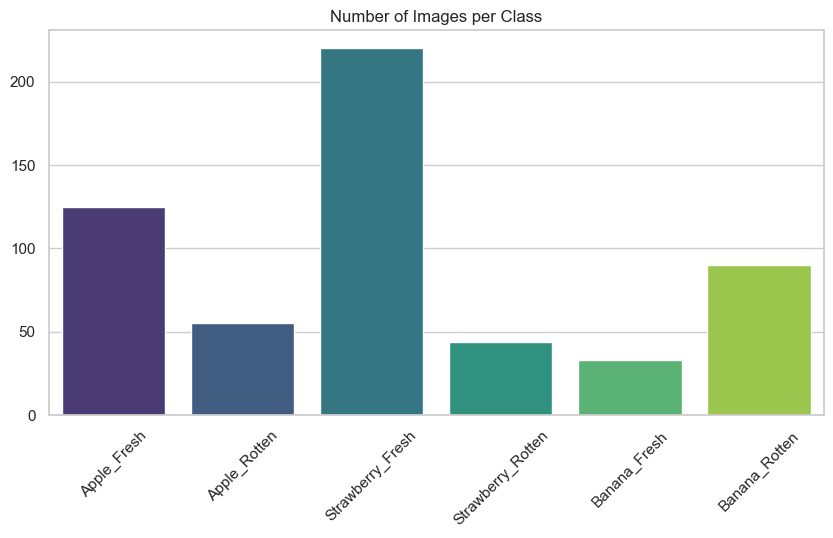

In [6]:
# class distribution
class_counts = {label: len(os.listdir(path)) for label, path in zip(class_labels, class_paths)}

plt.figure(figsize=(10,5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title("Number of Images per Class")
plt.xticks(rotation=45)
plt.show()

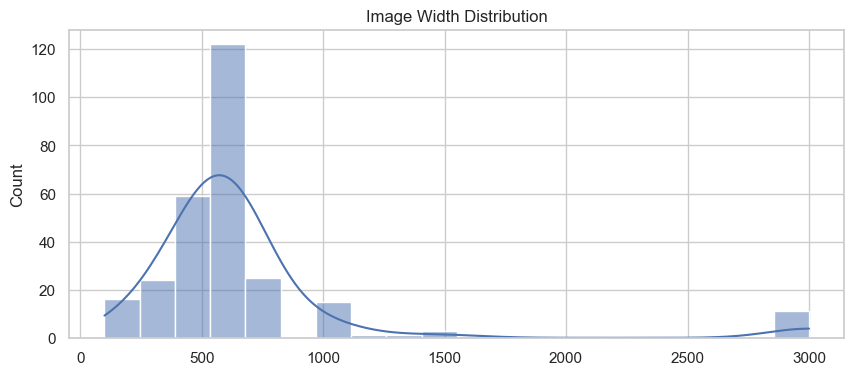

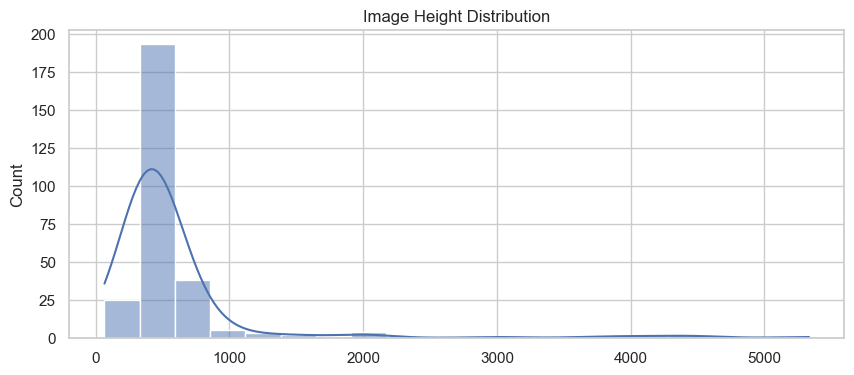

In [7]:
# image size analysis

widths, heights = [], []

for path in class_paths:
    for img_name in os.listdir(path)[:50]:  # sample to speed up
        img = Image.open(os.path.join(path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(10,4))
sns.histplot(widths, bins=20, kde=True)
plt.title("Image Width Distribution")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(heights, bins=20, kde=True)
plt.title("Image Height Distribution")
plt.show()

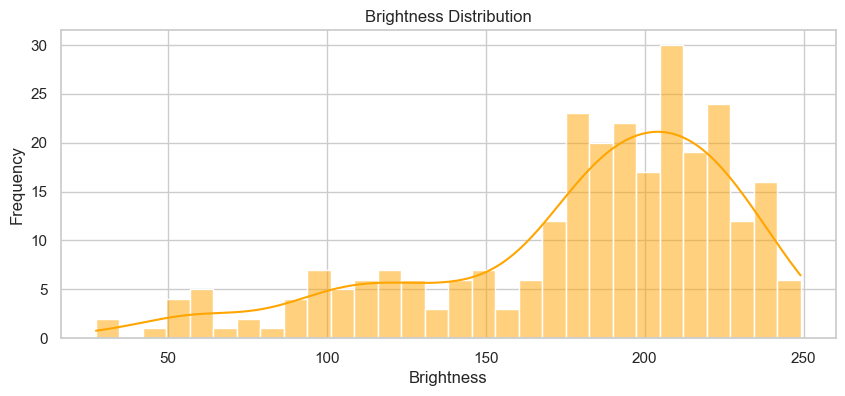

In [8]:
# image brightness analysis
brightness_values = []

for path in class_paths:
    for img_name in os.listdir(path)[:50]:
        img = Image.open(os.path.join(path, img_name))
        gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
        brightness_values.append(np.mean(gray))

plt.figure(figsize=(10,4))
sns.histplot(brightness_values, bins=30, kde=True, color="orange")
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

In [10]:
# build dataframe
import arrow
import base64
import pandas as pd
from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

THUMBNAIL_SIZE = (64, 64)

# build dataset: https://www.kaggle.com/code/mikedelong/f1-0-947-with-logistic-regression
def embed(model, filename: str):
    with Image.open(fp=filename, mode='r') as image:
        return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)

def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        # our images are pretty big; let's shrink the hover images to thumbnail size
        image.resize(size=THUMBNAIL_SIZE).convert('RGBA').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    time_get = arrow.now()
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'] )
        for index, input_file in enumerate(list(iglob(pathname=arg))) if input_file.endswith('.jpg') or input_file.endswith('.png')]
    print('encoded {} rows of {}  in {}'.format(len(result), tag, arrow.now() - time_get))
    return result

In [15]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np

# conda install -c pytorch pytorch
DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /Users/arielz/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████████████████████████████████| 95.8M/95.8M [00:01<00:00, 66.9MB/s]


In [16]:
banana_dict = {basename(folder) : folder + '/*.*' for folder in iglob(DATASET_PATH + '/*/*') if isdir(folder) and 'Banana' in folder}
banana_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for key, value in banana_dict.items()]))
apple_dict = {basename(folder) : folder + '/*.*' for folder in iglob(DATASET_PATH + '/*/*') if isdir(folder) and 'Apple' in folder}
apple_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for key, value in apple_dict.items()]))
strawberry_dict = {basename(folder) : folder + '/*.*' for folder in iglob(DATASET_PATH + '/*/*') if isdir(folder) and 'Strawberry' in folder}
strawberry_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for key, value in strawberry_dict.items()]))
train_df = pd.concat(axis='index', objs=[apple_df, banana_df, strawberry_df])

encoded 16 rows of Fresh  in 0:00:15.586477
encoded 90 rows of Rotten  in 0:01:09.586134
encoded 117 rows of Fresh  in 0:01:18.188476
encoded 53 rows of Rotten  in 0:00:31.955105
encoded 209 rows of Fresh  in 0:02:21.126321
encoded 44 rows of Rotten  in 0:00:29.903756


In [17]:
# build dataset
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2025, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 529 samples in 0.002s...
[t-SNE] Computed neighbors for 529 samples in 0.165s...
[t-SNE] Computed conditional probabilities for sample 529 / 529
[t-SNE] Mean sigma: 1.650158
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.892883
[t-SNE] KL divergence after 1000 iterations: 0.422635


In [18]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_df['value'].apply(pd.Series), train_df['tag'], test_size=0.25, random_state=2026, stratify=train_df['tag'])
logreg = LogisticRegression(max_iter=200, tol=1e-12).fit(X_train, y_train)
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=y_test, y_pred=logreg.predict(X=X_test))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=y_test, y_pred=logreg.predict(X=X_test))))
print(classification_report(y_true=y_test, y_pred=logreg.predict(X=X_test), zero_division=0.0))

model fit in 151 iterations
accuracy: 0.9624
f1: 0.9621
              precision    recall  f1-score   support

       Fresh       0.96      0.99      0.97        86
      Rotten       0.98      0.91      0.95        47

    accuracy                           0.96       133
   macro avg       0.97      0.95      0.96       133
weighted avg       0.96      0.96      0.96       133



<Axes: xlabel='probability', ylabel='Count'>

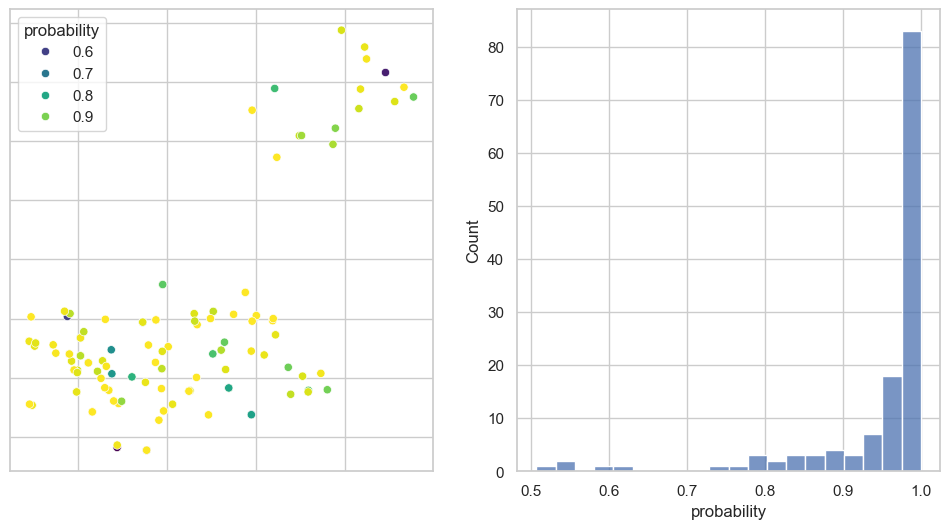

In [19]:
import matplotlib.pyplot as plt
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = train_df.iloc[X_test.index][['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=X_test), axis=1)

plt, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', )
ax[0].set(xlabel=None) 
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)
